# Student Performance Prediction Using Machine Learning

## Project Overview

This project uses Machine Learning to predict whether a student is likely to pass or fail based on academic and attendance-related factors.

The model uses Study Hours, Attendance, Assignment Score, and Previous Exam Score as input features.

A Random Forest Classifier is used to train the machine learning model and make predictions.

## Objectives

- Analyze student performance data.
- Clean and prepare the dataset.
- Visualize important relationships in the data.
- Train a Machine Learning classification model.
- Evaluate the model performance.
- Predict the result of a new student.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Study_Hours": [
        2, 3, 5, 6, 7, 1, 4, 8, 9, 2,
        6, 7, 3, 5, 8, 1, 4, 9, 6, 7,
        2, 5, 8, 3, 7, 9, 4, 6, 2, 8
    ],

    "Attendance": [
        55, 60, 75, 80, 85, 45, 70, 90, 95, 50,
        82, 88, 65, 78, 92, 40, 68, 96, 84, 89,
        58, 76, 94, 62, 86, 97, 72, 81, 52, 91
    ],

    "Assignment_Score": [
        45, 50, 68, 72, 80, 35, 65, 88, 92, 42,
        78, 85, 55, 70, 90, 30, 60, 94, 82, 87,
        48, 74, 95, 52, 83, 96, 67, 79, 40, 91
    ],

    "Previous_Exam_Score": [
        40, 45, 65, 70, 78, 30, 60, 85, 90, 38,
        75, 82, 50, 68, 88, 28, 58, 92, 80, 84,
        42, 72, 93, 48, 81, 95, 63, 76, 35, 89
    ],

    "Result": [
        "Fail", "Fail", "Pass", "Pass", "Pass", "Fail",
        "Pass", "Pass", "Pass", "Fail", "Pass", "Pass",
        "Fail", "Pass", "Pass", "Fail", "Fail", "Pass",
        "Pass", "Pass", "Fail", "Pass", "Pass", "Fail",
        "Pass", "Pass", "Pass", "Pass", "Fail", "Pass"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
df.head()

Dataset created successfully!


,Study_Hours,Attendance,Assignment_Score,Previous_Exam_Score,Result
0,2,55,45,40,Fail
1,3,60,50,45,Fail
2,5,75,68,65,Pass
3,6,80,72,70,Pass
4,7,85,80,78,Pass


In [3]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Study_Hours,Attendance,Assignment_Score,Previous_Exam_Score,Result
0,2,55,45,40,Fail
1,3,60,50,45,Fail
2,5,75,68,65,Pass
3,6,80,72,70,Pass
4,7,85,80,78,Pass


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(30, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Study_Hours          30 non-null     int64 
 1   Attendance           30 non-null     int64 
 2   Assignment_Score     30 non-null     int64 
 3   Previous_Exam_Score  30 non-null     int64 
 4   Result               30 non-null     object
dtypes: int64(4), object(1)
memory usage: 1.3+ KB

Statistical Summary:


,Study_Hours,Attendance,Assignment_Score,Previous_Exam_Score
count,30.000000,30.000000,30.000000,30.000000
mean,5.233333,75.200000,69.766667,66.666667
std,2.528231,16.386285,19.758339,20.705377
min,1.000000,40.000000,30.000000,28.000000
25%,3.000000,62.750000,52.750000,48.500000
50%,5.500000,79.000000,73.000000,71.000000
75%,7.000000,88.750000,86.500000,83.500000
max,9.000000,97.000000,96.000000,95.000000


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Study_Hours            0
Attendance             0
Assignment_Score       0
Previous_Exam_Score    0
Result                 0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
print(df["Result"].value_counts())

Result
Pass    20
Fail    10
Name: count, dtype: int64


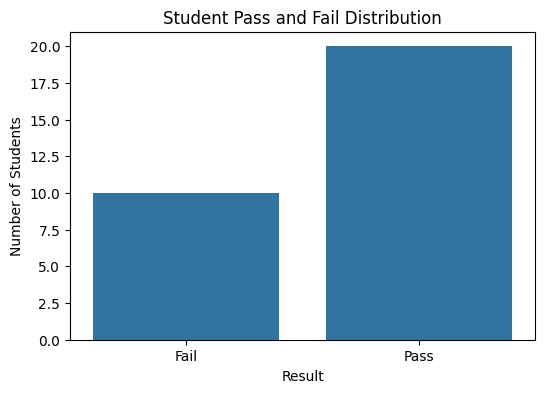

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Result")

plt.title("Student Pass and Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

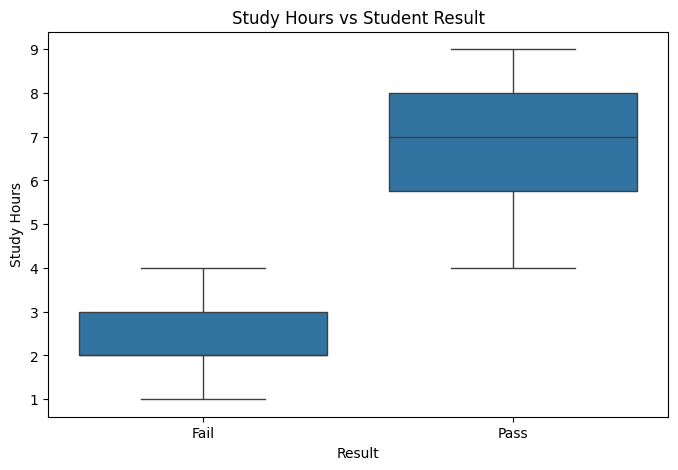

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Result", y="Study_Hours")

plt.title("Study Hours vs Student Result")
plt.xlabel("Result")
plt.ylabel("Study Hours")

plt.show()

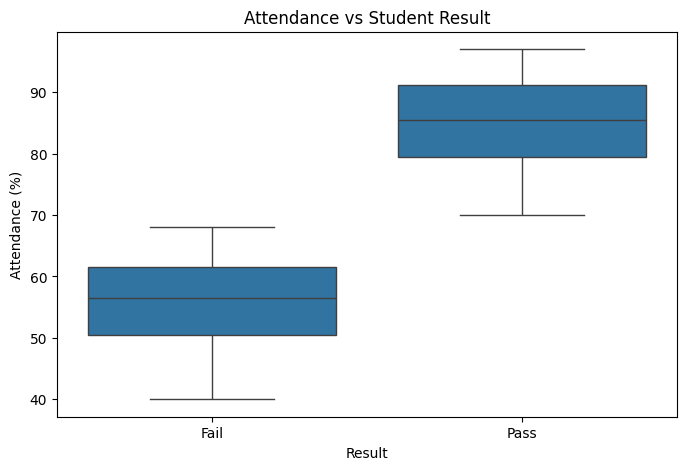

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Result", y="Attendance")

plt.title("Attendance vs Student Result")
plt.xlabel("Result")
plt.ylabel("Attendance (%)")

plt.show()

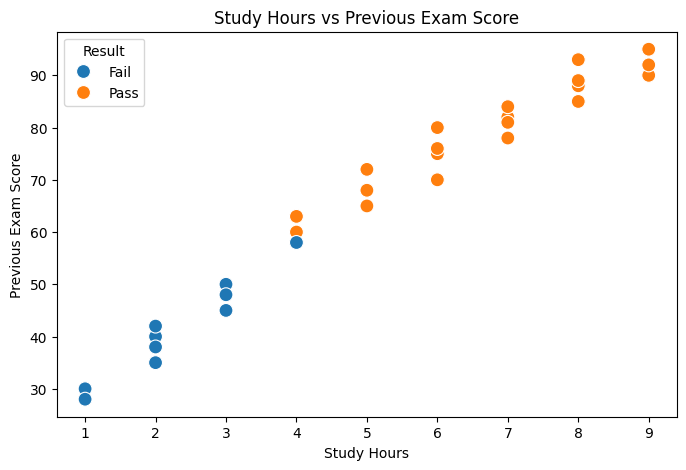

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Previous_Exam_Score",
    hue="Result",
    s=100
)

plt.title("Study Hours vs Previous Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Previous Exam Score")

plt.show()

In [12]:
df["Result_Number"] = df["Result"].map({
    "Fail": 0,
    "Pass": 1
})

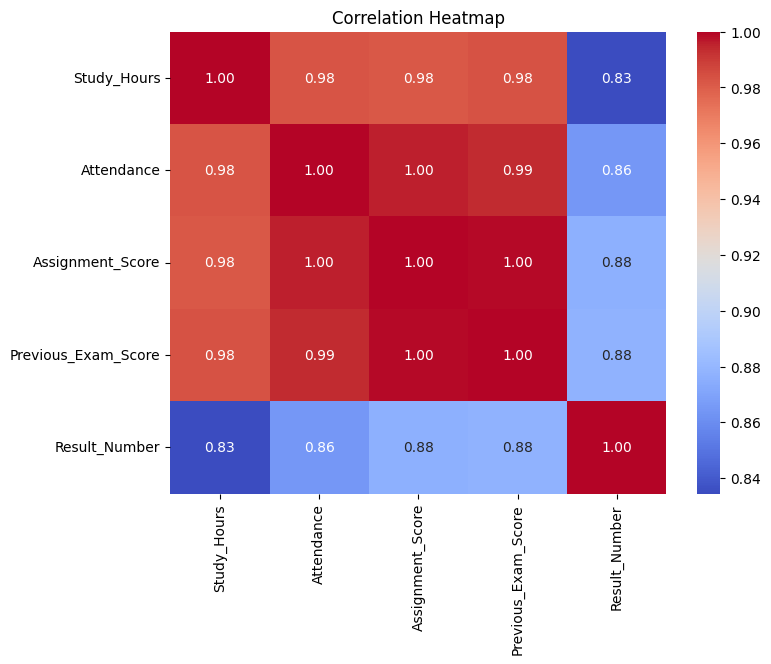

In [13]:
plt.figure(figsize=(8, 6))

correlation = df[
    [
        "Study_Hours",
        "Attendance",
        "Assignment_Score",
        "Previous_Exam_Score",
        "Result_Number"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
X = df[
    [
        "Study_Hours",
        "Attendance",
        "Assignment_Score",
        "Previous_Exam_Score"
    ]
]

y = df["Result"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Study_Hours,Attendance,Assignment_Score,Previous_Exam_Score
0,2,55,45,40
1,3,60,50,45
2,5,75,68,65
3,6,80,72,70
4,7,85,80,78



Target:


,Result
0,Fail
1,Fail
2,Pass
3,Pass
4,Pass


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [17]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['Fail' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass']


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


In [21]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



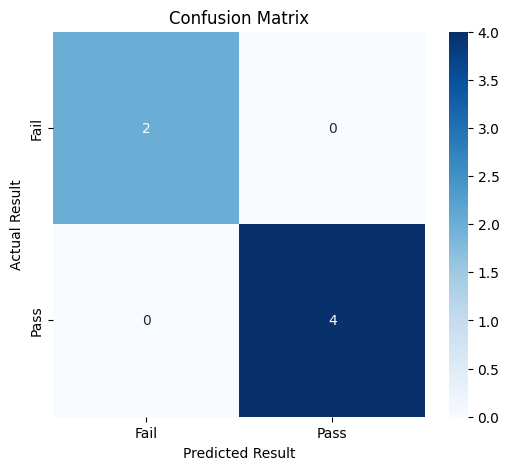

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Fail", "Pass"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")

plt.show()

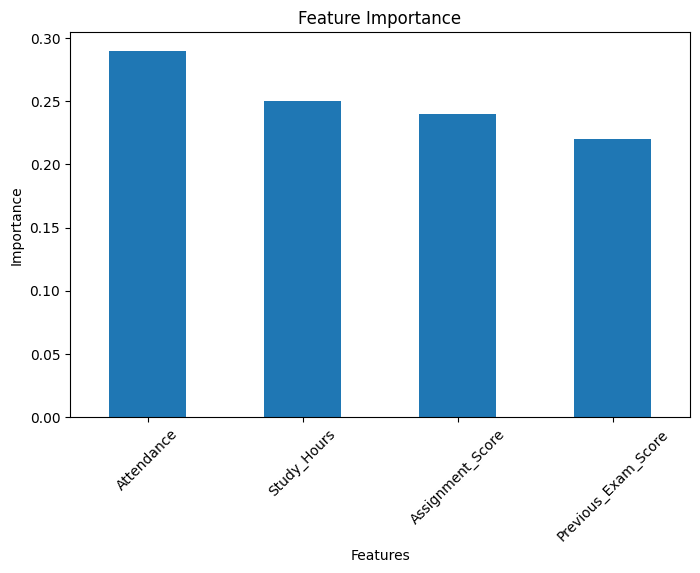

In [23]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [24]:
print("Enter details for a new student")

study_hours = float(input("Study Hours: "))
attendance = float(input("Attendance (%): "))
assignment_score = float(input("Assignment Score: "))
previous_exam_score = float(input("Previous Exam Score: "))

new_student = pd.DataFrame({
    "Study_Hours": [study_hours],
    "Attendance": [attendance],
    "Assignment_Score": [assignment_score],
    "Previous_Exam_Score": [previous_exam_score]
})

prediction = model.predict(new_student)

print("\nPredicted Result:", prediction[0])

Enter details for a new student
Study Hours: 4
Attendance (%): 70
Assignment Score: 40
Previous Exam Score: 60

Predicted Result: Pass


In [25]:
probabilities = model.predict_proba(new_student)[0]

for class_name, probability in zip(model.classes_, probabilities):
    print(f"{class_name}: {probability * 100:.2f}%")

Fail: 42.00%
Pass: 58.00%


# Final Results

The project successfully developed a Machine Learning model for predicting student performance.

The workflow included:

- Dataset creation
- Data exploration
- Data cleaning
- Data visualization
- Feature selection
- Train-test splitting
- Random Forest model training
- Prediction
- Accuracy evaluation
- Classification report
- Confusion matrix
- Feature importance
- New student prediction

The project demonstrates how Machine Learning can be applied to educational data for classification tasks.

# Conclusion

The Student Performance Prediction project demonstrates the complete Machine Learning workflow from data preparation to prediction.

A Random Forest Classifier was trained using study hours, attendance, assignment score, and previous exam score.

The model was evaluated using accuracy, classification report, and confusion matrix.

This project helped develop practical knowledge of Python, Pandas, data visualization, Scikit-learn, supervised learning, classification, and model evaluation.

The prediction should be considered an educational demonstration rather than a definitive assessment of a student's actual academic performance.